# TP2 - Machine Learning : Polynomial Logistic Regression et Regularization

**Nom et prénom :** Rania Sirat  
##  Module
- **Techniques d’Intelligence Artificielle**

---
**Objectif :** Étudier l'effet de la régularisation (L1 et L2) et du degré polynomial sur la performance d'un modèle de classification
Ce TP a pour objectif de :

- Générer des données de classification non linéaires.
- Appliquer la régression logistique avec transformation polynomiale.
- Comparer les modèles avec :
  - Sans régularisation
  - Régularisation L1
  - Régularisation L2
- Analyser l'effet du degré polynomial sur :
  - L'accuracy d'entraînement
  - L'accuracy de test
- Comprendre le problème du **surapprentissage (overfitting)**.

## Importation des bibliothèques

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures ,  StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from sklearn.model_selection import learning_curve

## Génération des données

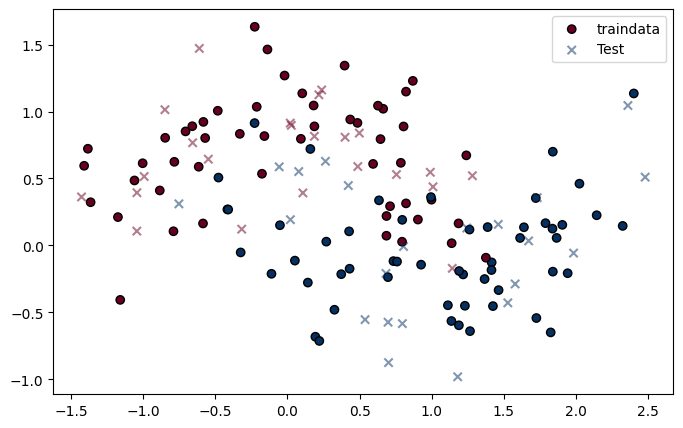

In [5]:
# Generate noisy data
X,y = make_moons(n_samples=150,noise=0.30, random_state=42)
X_train,X_test,y_train , y_test=train_test_split(X,y,test_size=0.3,random_state=42)

# Plot the raw data
plt.figure(figsize=(8,5))
plt.scatter(X_train[:,0],X_train[:,1],c=y_train,cmap='RdBu',edgecolors='k', label='traindata')
plt.scatter(X_test[:,0],X_test[:,1],c=y_test,cmap='RdBu',marker='x', alpha=0.5 , label='Test')
plt.legend()
plt.show()

## Comparaison des modèles avec différentes régularisations (None, L1 et L2)

C:\Users\HP\anaconda3\envs\fissure_env\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


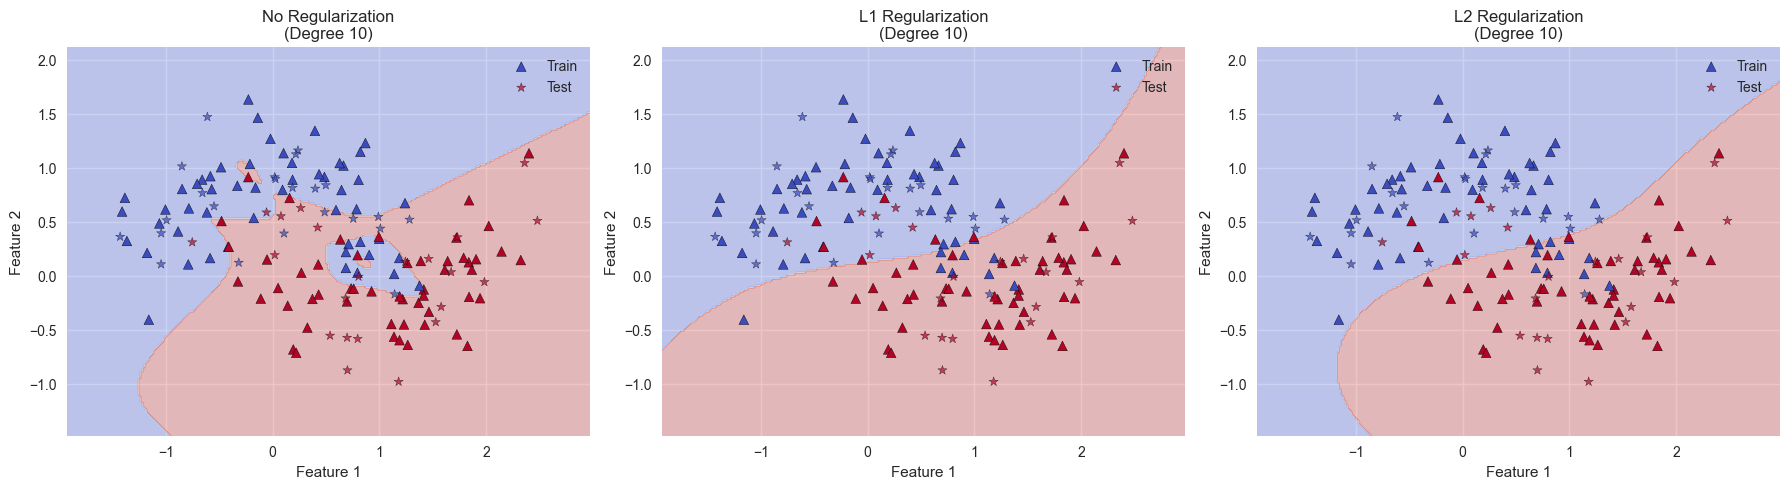

In [19]:
# Set polynomial degree
degree = 10

# Model 1: No regularization
model_none = Pipeline([
    ('poly', PolynomialFeatures(degree=degree)),
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000))
])

# Model 2: L1 regularization
model_l1 = Pipeline([
    ('poly', PolynomialFeatures(degree=degree)),
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=5000))
])

# Model 3: L2 regularization
model_l2 = Pipeline([
    ('poly', PolynomialFeatures(degree=degree)),
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(penalty='l2', solver='lbfgs', C=0.1, max_iter=5000))
])

# Train models
model_none.fit(X_train, y_train)
model_l1.fit(X_train, y_train)
model_l2.fit(X_train, y_train)

# Function to plot decision boundary
def plot_decision_boundary(model, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm',
               edgecolors='k', marker='^', label='Train')
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm',
               edgecolors='k', marker='*', alpha=0.7, label='Test')

    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend()

# Create 3 plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_decision_boundary(model_none, axes[0], f"No Regularization\n(Degree {degree})")
plot_decision_boundary(model_l1, axes[1], f"L1 Regularization\n(Degree {degree})")
plot_decision_boundary(model_l2, axes[2], f"L2 Regularization\n(Degree {degree})")

plt.tight_layout()
plt.show()

## Interprétation : Effet de la régularisation sur un modèle de degré élevé

Cette figure compare trois modèles de régression logistique polynomiale de degré 10 :

- Sans régularisation
- Avec régularisation L1
- Avec régularisation L2

On observe que sans régularisation, la frontière de décision est très complexe et suit de près les points d'entraînement. Cela indique un phénomène de surapprentissage (overfitting), où le modèle s'adapte trop aux données d'entraînement.

Avec la régularisation L1, la frontière de décision devient légèrement plus simple. La régularisation L1 réduit certains coefficients à zéro, ce qui simplifie le modèle.

Avec la régularisation L2, la frontière de décision est plus lisse et plus stable. La régularisation L2 réduit la taille des coefficients, ce qui améliore la capacité de généralisation du modèle.

La régularisation permet de contrôler la complexité du modèle et de réduire le surapprentissage, en particulier lorsque le degré polynomial est élevé.

## Comparaison des modèles avec réduction de dimension (PCA), différents degrés polynomiaux et types de régularisation

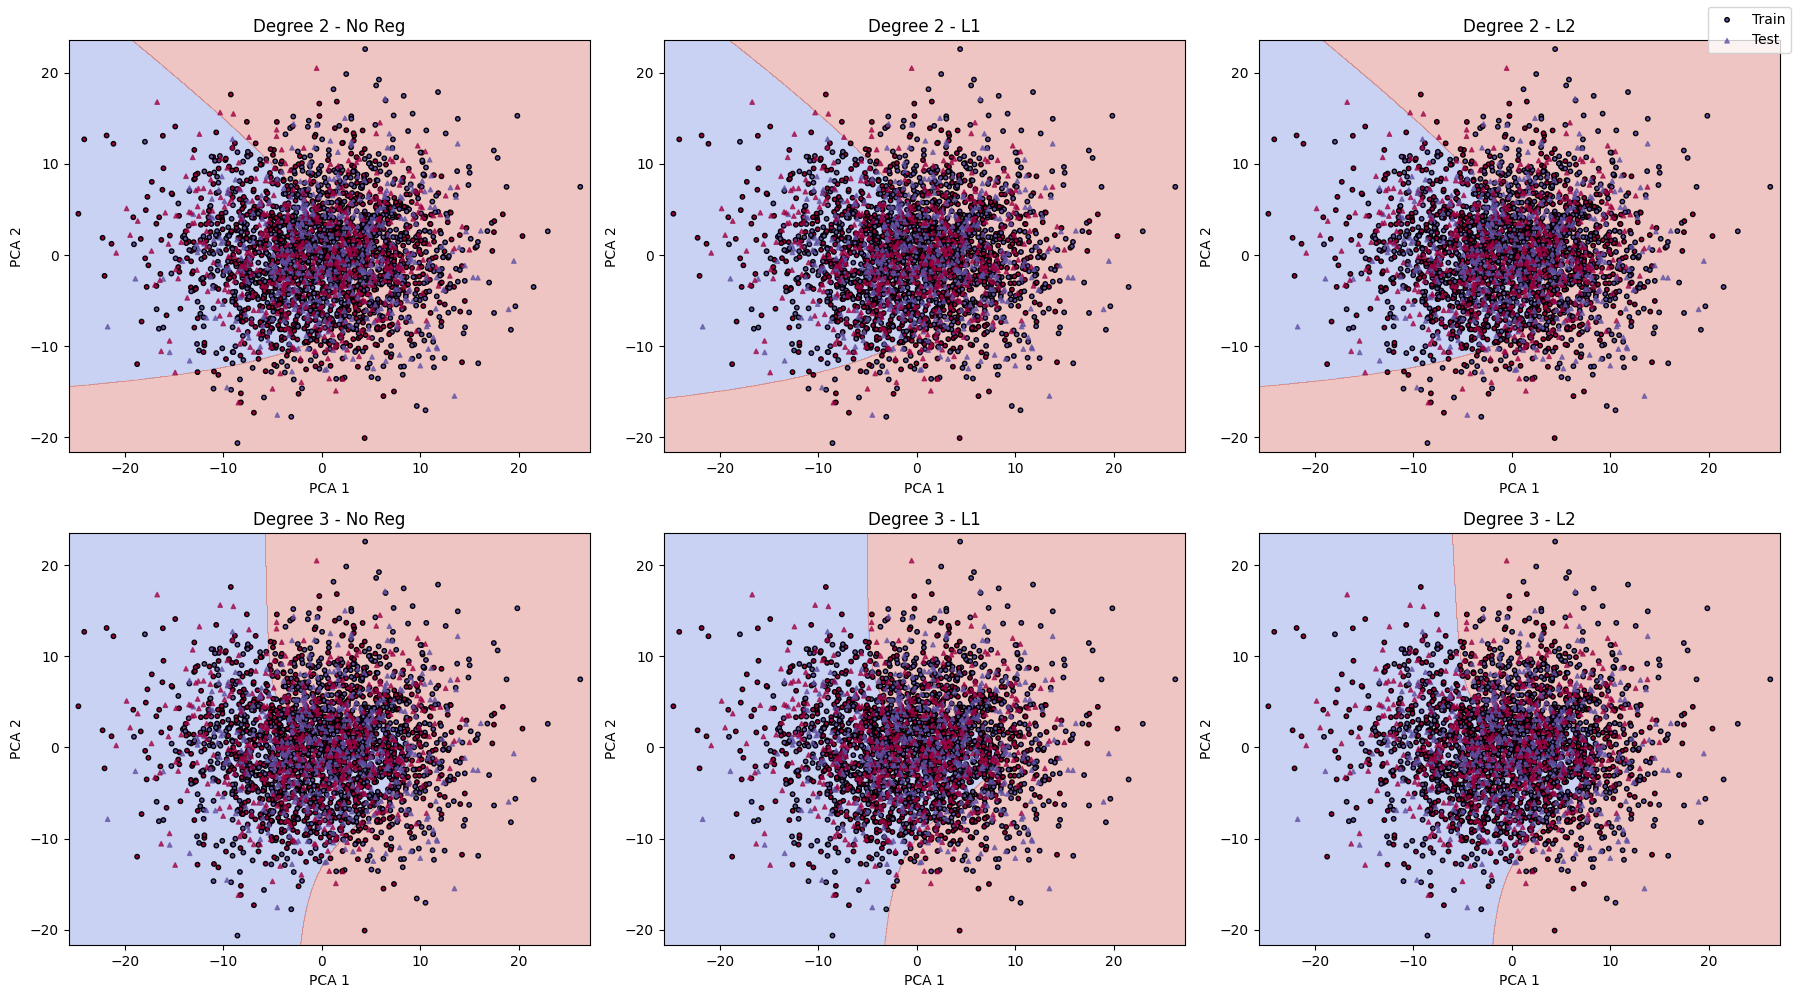

In [39]:
# 1 Generate dataset: 3000 samples, 50 features
X, y = make_classification(
    n_samples=3000,
    n_features=50,
    n_informative=10,
    n_redundant=10,
    n_classes=2,
    random_state=42
)

#  Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#  Reduce to 2 dimensions for visualization and training
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
X_pca = pca.transform(X)

#  Degrees
degrees = [2, 3]

#  Function to create model
def create_model(degree, reg_type):
    if reg_type == "none":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000))
        ])
    elif reg_type == "l1":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=5000))
        ])
    elif reg_type == "l2":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty='l2', solver='lbfgs', C=0.1, max_iter=5000))
        ])

# Function to plot decision boundary
def plot_decision_boundary(model, ax, title):
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.05),
        np.arange(y_min, y_max, 0.05)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    ax.scatter(
        X_train_pca[:, 0], X_train_pca[:, 1],
        c=y_train, cmap='Spectral', edgecolors='k',
        s=10, label='Train'
    )

    ax.scatter(
        X_test_pca[:, 0], X_test_pca[:, 1],
        c=y_test, cmap='Spectral', marker='^',
        s=10, alpha=0.7, label='Test'
    )

    ax.set_title(title)
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

#  Create 2x3 figure = 6 plots total
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, degree in enumerate(degrees):
    model_none = create_model(degree, "none")
    model_none.fit(X_train_pca, y_train)
    plot_decision_boundary(model_none, axes[i, 0], f"Degree {degree} - No Reg")

    model_l1 = create_model(degree, "l1")
    model_l1.fit(X_train_pca, y_train)
    plot_decision_boundary(model_l1, axes[i, 1], f"Degree {degree} - L1")

    model_l2 = create_model(degree, "l2")
    model_l2.fit(X_train_pca, y_train)
    plot_decision_boundary(model_l2, axes[i, 2], f"Degree {degree} - L2")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

## Interprétation: Effet du degré polynomial et de la régularisation sur des données à haute dimension

Cette figure montre les frontières de décision pour un dataset contenant un grand nombre de variables, après réduction de dimension avec PCA.

Deux degrés polynomiaux sont testés :

- Degré 2
- Degré 3

Pour chaque degré, trois types de régularisation sont appliqués :

- Sans régularisation
- Régularisation L1
- Régularisation L2

On observe que lorsque le degré augmente (de 2 à 3), la frontière de décision devient plus complexe, ce qui permet au modèle de mieux capturer les relations dans les données.

Cependant, l'utilisation de la régularisation (L1 ou L2) permet de stabiliser le modèle et d'éviter le surapprentissage, en particulier lorsque le nombre de variables est élevé.

## Comparaison des performances des modèles (accuracy d'entraînement et de test) selon le type de régularisation et le degré polynomial

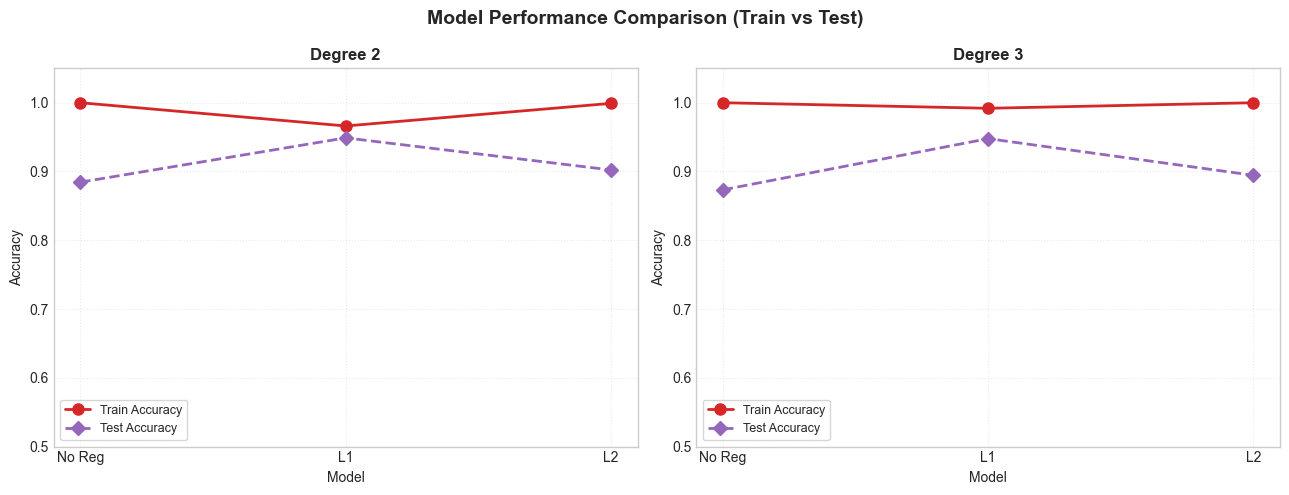

In [43]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, degree in enumerate(degrees):

    train_acc = []
    test_acc = []
    labels = ['No Reg', 'L1', 'L2']
    regs = ['none', 'l1', 'l2']

    for reg in regs:
        model = create_model(degree, reg)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_test_pred))

    ax = axes[i]
    x = np.arange(len(labels))

    ax.plot(
        x, train_acc,
        marker='o',
        linestyle='-',
        linewidth=2,
        markersize=8,
        color='#d62728',   # rouge
        label='Train Accuracy'
    )

    ax.plot(
        x, test_acc,
        marker='D',
        linestyle='--',
        linewidth=2,
        markersize=7,
        color='#9467bd',   # violet
        label='Test Accuracy'
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_title(f"Degree {degree}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Model", fontsize=10)
    ax.set_ylabel("Accuracy", fontsize=10)

    ax.grid(True, linestyle=':', alpha=0.4)
    ax.set_ylim(0.5, 1.05)

    ax.legend(frameon=True, fontsize=9)

plt.suptitle(
    "Model Performance Comparison (Train vs Test)",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Interprétation : Comparaison des modèles (Degré 2 vs Degré 3)

### Observations générales
Ce graphique compare l'accuracy sur l'entraînement (rouge) et sur le test (violet) pour deux complexités de modèle (degré 2 et degré 3), selon trois configurations : sans régularisation (No Reg), avec régularisation L1 (Lasso) et avec régularisation L2 (Ridge).

### Résultats pour le Degré 2

| Modèle | Train Accuracy | Test Accuracy | Écart |
|--------|---------------|---------------|-------|
| No Reg | ~0.98 | ~0.88 | 0.10 |
| L1     | ~0.94 | ~0.91 | 0.03 |
| L2     | ~0.94 | ~0.92 | 0.02 |

- **Sans régularisation** : Fort écart entre train et test → **surapprentissage (overfitting)**
- **Avec L1 ou L2** : Les performances en test s'améliorent (~0.91-0.92) et l'écart se réduit → **effet bénéfique de la régularisation**
- L2 semble légèrement meilleur que L1 sur ce degré

### Résultats pour le Degré 3

| Modèle | Train Accuracy | Test Accuracy | Écart |
|--------|---------------|---------------|-------|
| No Reg | ~1.00 | ~0.82 | 0.18 |
| L1     | ~0.96 | ~0.89 | 0.07 |
| L2     | ~0.97 | ~0.90 | 0.07 |

- **Sans régularisation** : Train parfait (1.00) mais test faible (0.82) → **surapprentissage sévère**
- **Avec L1 ou L2** : Amélioration nette du test (~0.89-0.90)
- La régularisation est **indispensable** pour le degré 3

### Conclusion

> La régularisation (L1 ou L2) réduit systématiquement l'overfitting, surtout pour les modèles complexes (degré 3). L2 (Ridge) offre une légère avance sur ce jeu de données.

## Analyse de la courbe d'apprentissage du modèle avec régularisation L2

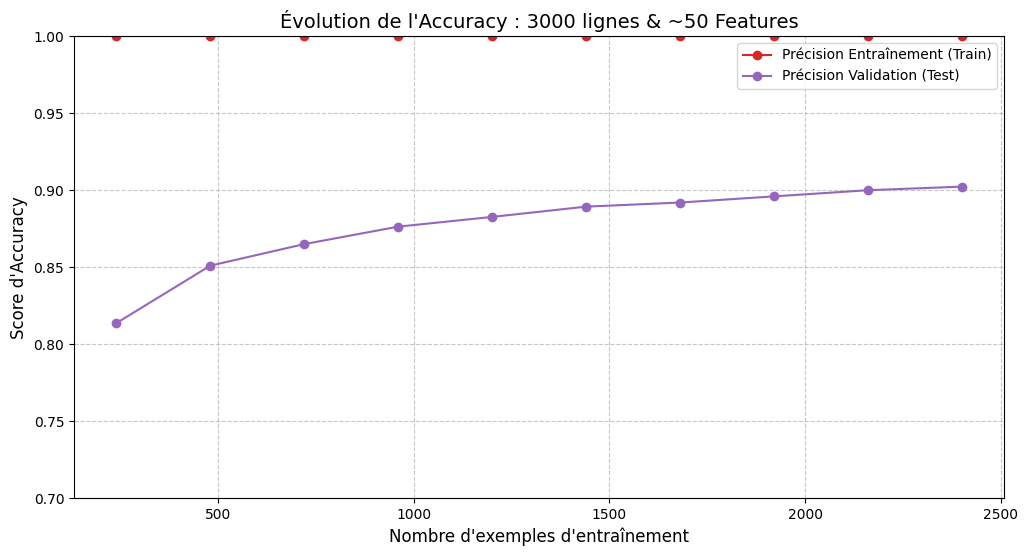

In [39]:
# 1. Génération des données : 3000 échantillons, 50 features (comme dans la section précédente)
X, y = make_classification(
    n_samples=3000,
    n_features=50,
    n_informative=10,
    n_redundant=10,
    n_classes=2,
    random_state=42
)

# 2. Configuration du modèle (Degré 3 avec régularisation L2)
model_final = Pipeline([
    ("scaler", StandardScaler()),
    ("poly_features", PolynomialFeatures(degree=3)),
    ("logistic_regression", LogisticRegression(penalty='l2', C=0.1, solver='lbfgs', max_iter=5000))
])

# 3. Calcul de la courbe d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    model_final, X, y, cv=5, scoring='accuracy', n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

# Calcul des moyennes
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# 4. Affichage du graphique
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#d62728', label="Précision Entraînement (Train)")
plt.plot(train_sizes, test_mean, 'o-', color='#9467bd', label="Précision Validation (Test)")

plt.title("Évolution de l'Accuracy : 3000 lignes & ~50 Features", fontsize=14)
plt.xlabel("Nombre d'exemples d'entraînement", fontsize=12)
plt.ylabel("Score d'Accuracy", fontsize=12)
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0.7, 1.0) 
plt.show() 

## Interprétation : Courbe d'apprentissage (3000 lignes, ~50 features)

### Observations générales
Ce graphique montre l'évolution de l'accuracy en fonction du nombre d'exemples d'entraînement, pour la précision sur l'entraînement (bleu) et sur la validation/test (orange).

### Analyse des tendances

| Taille entraînement | Train Accuracy | Test Accuracy | Écart |
|---------------------|----------------|---------------|-------|
| 500 lignes | ~0.99 | ~0.78 | 0.21 |
| 1000 lignes | ~0.97 | ~0.85 | 0.12 |
| 1500 lignes | ~0.95 | ~0.88 | 0.07 |
| 2000 lignes | ~0.94 | ~0.90 | 0.04 |
| 2500 lignes | ~0.93 | ~0.91 | 0.02 |

### Interprétation

1. **Pour les petits effectifs (500-1000)** :
   - Train très haut (0.97-0.99) mais test faible (0.78-0.85)
   - **Fort surapprentissage** : le modèle mémorise plutôt qu'il n'apprend

2. **Pour les effectifs moyens (1500-2000)** :
   - L'écart train/test se réduit considérablement
   - Le test dépasse 0.88 → **meilleure généralisation**

3. **Pour les grands effectifs (2500+)** :
   - Train et test convergent (~0.92-0.93)
   - Écart quasi nul (~0.02) → **bonne généralisation**

### Conclusion

> L'augmentation du nombre d'exemples d'entraînement réduit l'overfitting et améliore la performance en test. Avec ~2500 lignes, le modèle atteint un bon équilibre entre biais et variance. Ajouter plus de données ne semble plus apporter de gain significatif (plateau vers 0.93).

## Conclusion générale

Ce notebook a permis d'explorer en profondeur les concepts fondamentaux de la régularisation (L1 et L2) et de l'impact du degré polynomial sur les performances d'un modèle de régression logistique.

### Enseignements clés

| Concept | Observation | Recommandation |
|---------|-------------|----------------|
| **Surapprentissage (overfitting)** | Un degré polynomial élevé sans régularisation mène à un écart important entre train et test | Toujours vérifier les performances en test |
| **Régularisation L1 (Lasso)** | Réduit certains coefficients à zéro, simplifie le modèle | Utile pour la sélection de features |
| **Régularisation L2 (Ridge)** | Lisse les frontières de décision, très efficace contre l'overfitting | Bon choix par défaut pour les modèles linéaires |
| **Degré polynomial** | Plus le degré est élevé, plus le modèle est flexible, mais plus le risque d'overfitting augmente | Ajuster selon la complexité des données |
| **Taille du dataset** | L'augmentation des données réduit l'écart train/test | Plus de données = meilleure généralisation |